In [1]:
import numpy as np
from collections import deque

# State Status Constants
STATE_OPEN = 0
STATE_STATIC_WALL = 1
STATE_PRUNED_WALL = 2
STATE_REACTIVATED = 3

class ResearchGridWorld:
    def __init__(self, size=30):
        self.size = size
        self.start_pos = (15, 15)
        # The door is 3 grids wide on the right wall
        self.doors = [(29, 14), (29, 15), (29, 16)] 
        
        # Initialize grid status matrix
        self.grid_status = np.full((size, size), STATE_OPEN)
        
        # Build outer walls
        for i in range(size):
            self.grid_status[0, i] = STATE_STATIC_WALL
            self.grid_status[size-1, i] = STATE_STATIC_WALL
            self.grid_status[i, 0] = STATE_STATIC_WALL
            self.grid_status[i, size-1] = STATE_STATIC_WALL
            
        # Re-open the doors in the wall boundary
        for door in self.doors:
            self.grid_status[door] = STATE_OPEN

    def is_path_clear_bfs(self, tentative_blocks=None):
        """
        Graph theory check: If we block 'tentative_blocks', 
        is there still a valid path from center to any door?
        """
        # Create a temporary copy of our map
        temp_grid = self.grid_status.copy()
        if tentative_blocks:
            for (x, y) in tentative_blocks:
                # Only prune open spaces, never touch doors or start coordinates
                if (x, y) != self.start_pos and (x, y) not in self.doors:
                    temp_grid[x, y] = STATE_PRUNED_WALL
                    
        # Classical BFS algorithm
        queue = deque([self.start_pos])
        visited = set([self.start_pos])
        
        while queue:
            curr = queue.popleft()
            if curr in self.doors:
                return True # A path safely exists!
                
            # Check 4 cardinal directions
            for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                nxt = (curr[0] + dx, curr[1] + dy)
                if 0 <= nxt[0] < self.size and 0 <= nxt[1] < self.size:
                    # Can walk if state is OPEN or REACTIVATED
                    if temp_grid[nxt] in [STATE_OPEN, STATE_REACTIVATED] and nxt not in visited:
                        visited.add(nxt)
                        queue.append(nxt)
                        
        return False # The door would be blocked! Reject pruning.

In [2]:
import random

class DSSP_Agent:
    def __init__(self, grid_size=30, alpha=0.1, gamma=0.95, epsilon=0.1):
        self.grid_size = grid_size
        self.alpha = alpha     # Learning rate
        self.gamma = gamma     # Discount factor
        self.epsilon = epsilon # Exploration rate
        
        # 4 Actions: 0=Up, 1=Down, 2=Left, 3=Right
        self.actions = [0, 1, 2, 3]
        
        # Initialize Q-table: (30, 30, 4) matrix filled with zeros
        self.q_table = np.zeros((grid_size, grid_size, 4))
        
        # Memory to track the current path for potential pruning
        self.current_episode_path = set()

    def select_action(self, state, env):
        """Selects an action using epsilon-greedy policy."""
        x, y = state
        
        # Exploration: pick a random action
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        
        # Exploitation: pick the action with the highest Q-value
        q_values = self.q_table[x, y]
        max_q = np.max(q_values)
        
        # Handle ties randomly to prevent deterministic loops early on
        candidates = [a for a in self.actions if q_values[a] == max_q]
        return random.choice(candidates)

    def update_q(self, state, action, reward, next_state):
        """Standard Q-learning formula execution."""
        x, y = state
        nx, ny = next_state
        
        best_next_q = np.max(self.q_table[nx, ny])
        old_q = self.q_table[x, y, action]
        
        # Temporal Difference (TD) Update
        self.q_table[x, y, action] = old_q + self.alpha * (reward + self.gamma * best_next_q - old_q)

In [3]:
# We add these methods to our environment to handle active simulation steps
def step(env, state, action):
    """Executes a movement step in the environment."""
    x, y = state
    # 0=Up, 1=Down, 2=Left, 3=Right
    movements = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    dx, dy = movements[action]
    
    next_state = (x + dx, y + dy)
    
    # Check if next step hits outer boundaries or static walls
    if (not (0 <= next_state[0] < env.size and 0 <= next_state[1] < env.size)) or \
       env.grid_status[next_state] == STATE_STATIC_WALL:
        return state, -1, False # Hit a hard wall, stay in place, minor penalty
        
    # Check if next step hits a space we have already pruned out
    if env.grid_status[next_state] == STATE_PRUNED_WALL:
        return state, -2, False # Heavier penalty for trying to go into forbidden zone
        
    # Check if agent reached the goal (the door)
    if next_state in env.doors:
        return next_state, 100, True # Major success reward!
        
    # Normal empty tile step
    return next_state, -1, False

def prune_failed_paths(env, accumulated_failed_paths):
    """
    Looks at all spaces visited during failed batches, 
    verifies safety via BFS, and seals them.
    """
    pruned_count = 0
    # Attempt to block tiles that were used in failures
    if env.is_path_clear_bfs(tentative_blocks=accumulated_failed_paths):
        for (x, y) in accumulated_failed_paths:
            if (x, y) != env.start_pos and (x, y) not in env.doors:
                if env.grid_status[x, y] == STATE_OPEN:
                    env.grid_status[x, y] = STATE_PRUNED_WALL
                    pruned_count += 1
    return pruned_count

# Bind these functions dynamically to our environment class
ResearchGridWorld.step = step
ResearchGridWorld.prune_failed_paths = prune_failed_paths

In [4]:

def run_experiment():
    # 1. Initialize our custom environment and agent
    env = ResearchGridWorld(size=30)
    agent = DSSP_Agent(grid_size=30)
    
    batch_size = 20
    total_episodes = 800
    max_steps_per_episode = 150
    
    # Storage for metrics we will plot in our paper
    steps_history = []
    pruned_tiles_history = []
    
    accumulated_failed_paths = set()
    batch_success_count = 0
    
    print(" Starting Training Loop using DSSP-LR Framework...")
    
    for episode in range(1, total_episodes + 1):
        state = env.start_pos
        episode_path = set([state])
        is_success = False
        
        # --- PHASE: SURPRISE OBSTACLE DROP ---
        # At episode 400, a dynamic wall drops blocking the main direct line to the door
        if episode == 400:
            print("\n [Environment Change] Dropping a surprise obstacle blocking the main path!")
            # Put a solid wall line at x=25 from y=10 to y=20
            for y_wall in range(10, 21):
                env.grid_status[25, y_wall] = STATE_STATIC_WALL
                
            # --- FEATURE: LOCALIZED OPTIMISTIC REACTIVATION ---
            # Automatically find pruned walls within a radius of 4 units from the obstacle and reactivate them
            reactivated_count = 0
            radius = 4
            for x in range(25 - radius, 25 + radius + 1):
                for y in range(15 - radius, 15 + radius + 1):
                    if 0 <= x < env.size and 0 <= y < env.size:
                        if env.grid_status[x, y] == STATE_PRUNED_WALL:
                            env.grid_status[x, y] = STATE_REACTIVATED
                            reactivated_count += 1
                            # Inject Maximum Optimistic Value to jumpstart curiosity
                            agent.q_table[x, y, :] = 150.0 
            print(f" [DSSP-LR Triggered] Reactivated {reactivated_count} surrounding tiles with Optimistic Q-values!")

        # --- PHASE: RUN EPISODE ---
        for step_num in range(max_steps_per_episode):
            action = agent.select_action(state, env)
            next_state, reward, done = env.step(state, action)
            
            # Remember the paths taken
            episode_path.add(next_state)
            
            # Update Q-table
            agent.update_q(state, action, reward, next_state)
            state = next_state
            
            if done:
                is_success = True
                break
                
        steps_history.append(step_num + 1)
        
        # Track batch statistics
        if is_success:
            batch_success_count += 1
        else:
            # If the episode was a total failure, collect its path for potential pruning
            accumulated_failed_paths.update(episode_path)
            
        # --- PHASE: END OF BATCH PROCESSING ---
        if episode % batch_size == 0:
            # If the agent failed more than 60% of the batch, prune its useless spaces
            if batch_success_count / batch_size < 0.40:
                new_pruned = env.prune_failed_paths(accumulated_failed_paths)
            else:
                new_pruned = 0
                
            total_pruned_so_far = np.sum(env.grid_status == STATE_PRUNED_WALL)
            pruned_tiles_history.append(total_pruned_so_far)
            
            # Reset batch buffers
            accumulated_failed_paths = set()
            batch_success_count = 0
            
            # Print periodic updates for our logs
            if episode % 100 == 0:
                print(f"Episode {episode}/{total_episodes} | Steps Last Ep: {step_num+1} | Total Pruned States: {total_pruned_so_far}")
                
    return steps_history, pruned_tiles_history, env

# Execute the experiment
steps, pruned_log, finalized_env = run_experiment()

 Starting Training Loop using DSSP-LR Framework...
Episode 100/800 | Steps Last Ep: 65 | Total Pruned States: 0
Episode 200/800 | Steps Last Ep: 150 | Total Pruned States: 0
Episode 300/800 | Steps Last Ep: 64 | Total Pruned States: 0

 [Environment Change] Dropping a surprise obstacle blocking the main path!
 [DSSP-LR Triggered] Reactivated 0 surrounding tiles with Optimistic Q-values!
Episode 400/800 | Steps Last Ep: 150 | Total Pruned States: 0
Episode 500/800 | Steps Last Ep: 150 | Total Pruned States: 0
Episode 600/800 | Steps Last Ep: 150 | Total Pruned States: 0
Episode 700/800 | Steps Last Ep: 150 | Total Pruned States: 0
Episode 800/800 | Steps Last Ep: 150 | Total Pruned States: 0


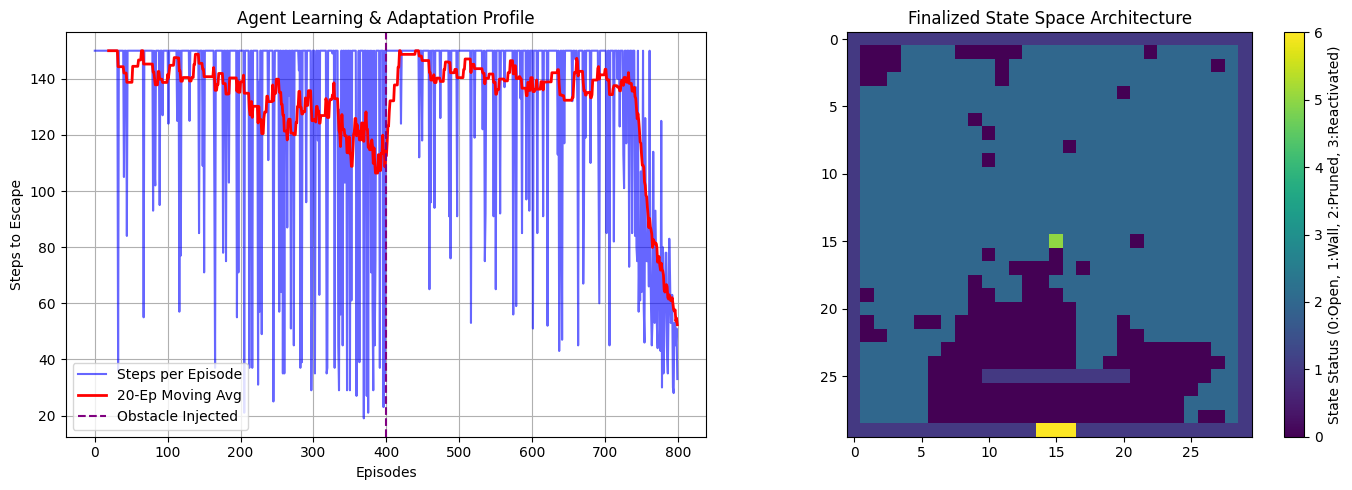

In [5]:
import matplotlib.pyplot as plt

# Create figures for the academic paper
plt.figure(figsize=(14, 5))

# Graph 1: Convergence and Adaptation Speed
plt.subplot(1, 2, 1)
plt.plot(steps, color='blue', alpha=0.6, label='Steps per Episode')
# Rolling average to smooth out exploration noise
rolling_avg = np.convolve(steps, np.ones(20)/20, mode='valid')
plt.plot(range(19, len(steps)), rolling_avg, color='red', linewidth=2, label='20-Ep Moving Avg')
plt.axvline(x=400, color='purple', linestyle='--', label='Obstacle Injected')
plt.title('Agent Learning & Adaptation Profile')
plt.xlabel('Episodes')
plt.ylabel('Steps to Escape')
plt.legend()
plt.grid(True)

# Graph 2: The Grid State Map Visualization
plt.subplot(1, 2, 2)
# Create a visual map matrix for visualization
visual_map = finalized_env.grid_status.copy()
# Highlight start and door positions
visual_map[finalized_env.start_pos] = 5 
for door in finalized_env.doors:
    visual_map[door] = 6

plt.imshow(visual_map, cmap='viridis')
plt.title('Finalized State Space Architecture')
plt.colorbar(label='State Status (0:Open, 1:Wall, 2:Pruned, 3:Reactivated)')

plt.tight_layout()
plt.show()